In [1]:
import os
import sys
import torch
import numpy as np
import scipy.io
import h5py
import argparse
from random import SystemRandom

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.distributions.normal import Normal
from torch.distributions import kl_divergence

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from lib.functions import *
from lib.utils import *
from lib.ProposeModel import *
from lib.BaselineModel import *

# Generative model for noisy data based on ODE
parser = argparse.ArgumentParser('Latent Neural Operator')
parser.add_argument('--niters', type=int, default=500)
parser.add_argument('--batch_size', type=int, default=50)
parser.add_argument('--lr',  type=float, default=1e-2, help="Starting learning rate.")

parser.add_argument('--input_dim', type=int, default=1, help="Dimensionality of the input system.")
parser.add_argument('--rec_dims', type=int, default=32, help="Dimensionality of the recognition model (NO or RNN).")
parser.add_argument('--latents', type=int, default=32, help="Size of the latent state")
parser.add_argument('--gru_units', type=int, default=100, help="Number of units per layer in each of GRU update networks")
parser.add_argument('--rec_len', type=int, default=20, help="The length of observation data")
parser.add_argument('--n_traj_samples', type=int, default=5, help="The number of trajectory samples")
parser.add_argument('--noise_weight', type=float, default=0.1, help="Noise amplitude for generated traejctories")

if 'ipykernel' in sys.modules:
    args = parser.parse_args([])
else:
    args = parser.parse_args()
    
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# read dataset
def read_data():
    dataset_GT = np.load('data/period.npy')
    dataset = dataset_GT.copy()
    noise = (np.random.sample(dataset.shape[:-1]) - 0.5)*2
    dataset[...,0] += args.noise_weight * noise
    
    train_size = int(dataset.shape[0] * 0.8)
    train_dataset = torch.tensor(dataset[:train_size])
    test_dataset = torch.tensor(dataset[train_size:])
    test_GT = dataset_GT[train_size:,:,:-1]
    
    print("dataset.shape:", dataset.shape)
    print("dataset_GT.shape", dataset_GT.shape)
    print("test_GT.shape", test_GT.shape)
    print("train_size:", train_size)
    return(train_dataset, test_dataset, test_GT)

train_dataset, test_dataset, test_GT = read_data()
args.input_dim = train_dataset.shape[-1] - 1

train_n = train_dataset.shape[0]
test_n = test_dataset.shape[0]
batch_size = min(args.batch_size, train_n)
train_dataloader = DataLoader(train_dataset.to(device), batch_size = args.batch_size, shuffle=True)
train_dataloader_iter = iter(train_dataloader)


dataset.shape: (3000, 100, 2)
dataset_GT.shape (3000, 100, 2)
test_GT.shape (600, 100, 1)
train_size: 2400


In [3]:
batch = test_dataset[:10]
batch_GT = test_GT[:10]

exps = [10000, 301, 302, 303, 305, 500]
models = [LatentNO_GRU(args, device), Vanilla_DeepONet1(args, device), Base_GRUDecay(args, device),
          Base_GRUVAE(args, device), Base_MLAE_LD(args, device, train_dataset, if_train_vae = False), Base_LODEGRU(args, device)]
labels = ['Proposed', 'DeepONet', 'GRUDecay', 'GRUVAE', 'MLAE', 'LNODE']

preds = []
for i in range(len(exps)):
    model = models[i]
    model.load_state_dict(torch.load('experiments/experiment_{}.ckpt'.format(exps[i]))['state_dict'])
    pred_y = model.test(batch.to(device)).cpu()
    preds.append(pred_y)
    

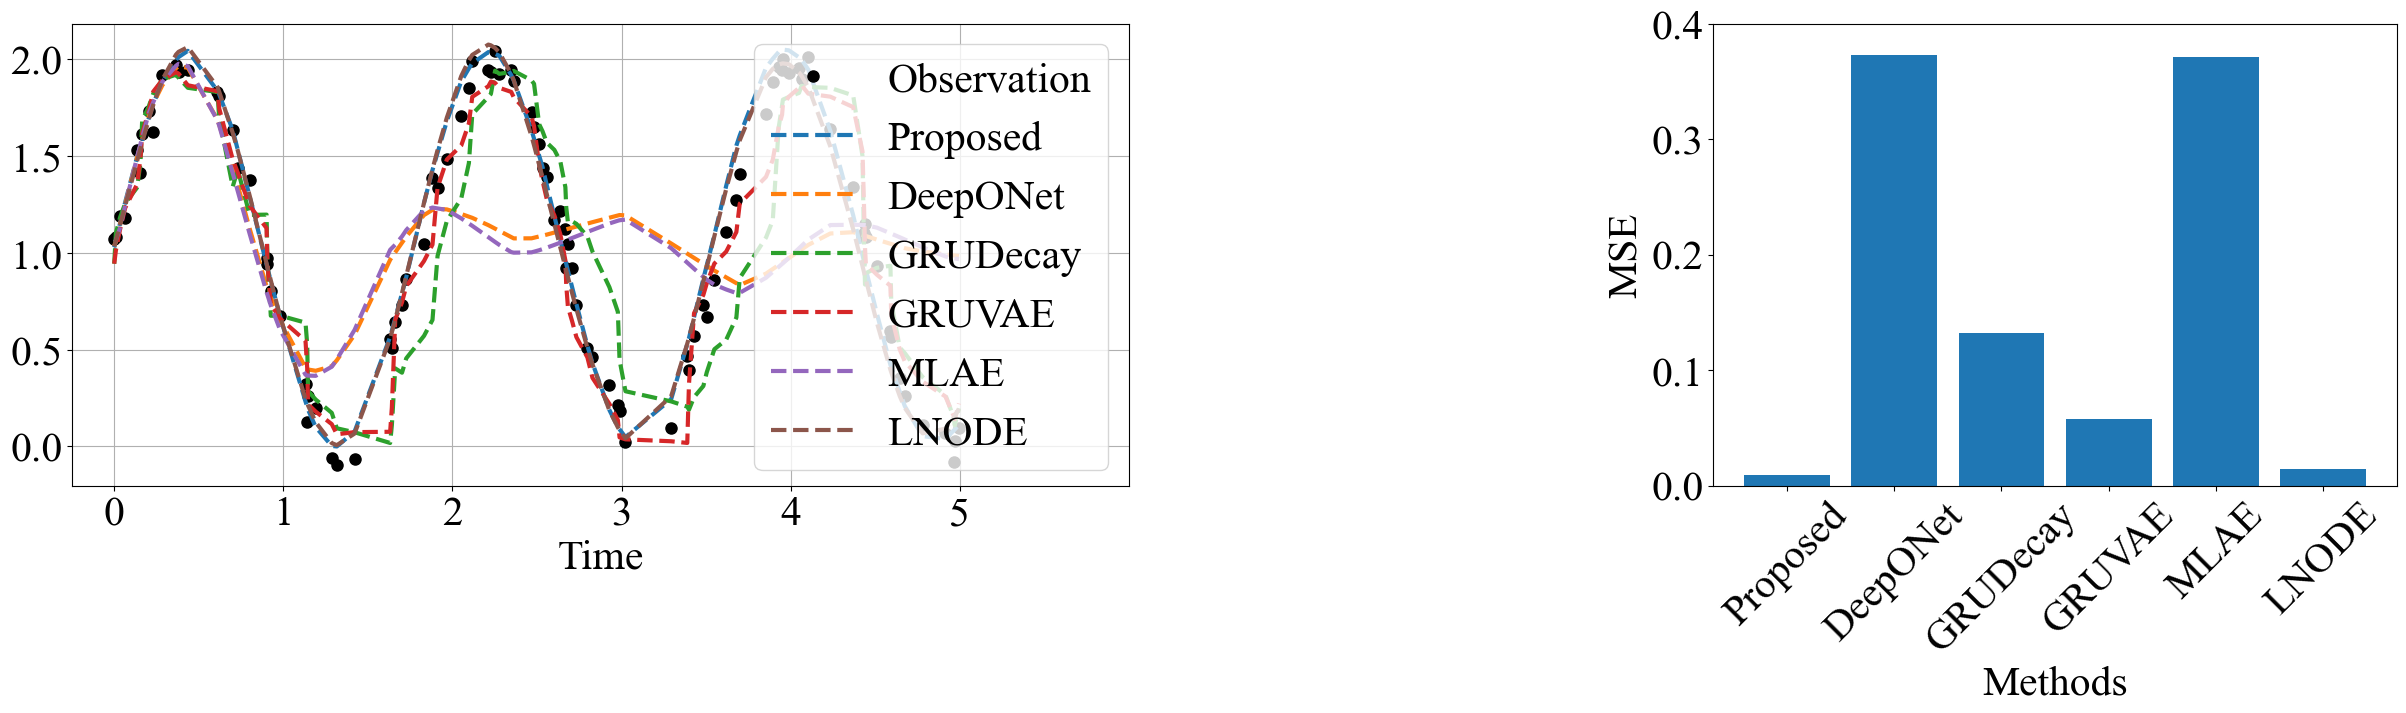

In [4]:
matplotlib.font_manager.fontManager.addfont('lib/fonts/times.ttf')

ms = 10
lw = 3
ls = 30
index = 8
s_GT = test_GT[index]
s = batch[index,:,0]
t = batch[index,:,-1]

fig = plt.figure(figsize=(30,6))
font1 = {'family':'Times New Roman', 'weight':'normal','size':ls}
plt.rcParams['font.family'] = 'Times New Roman'
#plt.plot(t, s_GT, 'k-')
#plt.plot(time_full[index], ps_full, 'rx', markersize=5)

ax1 = fig.add_subplot(1,2,1)
plt.plot(t, s, 'ko', markersize=8, label="Observation")
MSEs = []
for i in range(len(exps)):
    pred_y = preds[i]
    if len(pred_y.shape) == 4:
        plt.plot(t, pred_y[0,index], '--', markersize=ms, label=labels[i], linewidth=lw)
        msei = torch.mean((torch.mean(pred_y,axis=0)-batch_GT)**2)
    else:
        plt.plot(t, pred_y[index], '--', markersize=ms, label=labels[i], linewidth=lw)
        msei = torch.mean((pred_y-batch_GT)**2)
    MSEs.append(msei)
plt.xlim(None, 5.999)
plt.grid()
    
plt.legend(prop=font1)
plt.xlabel("Time", font1)
plt.tick_params(labelsize=ls)

ax1 = fig.add_subplot(1,3,3)
plt.bar(labels, MSEs)
plt.ylim([0,0.4])
plt.xlabel("Methods", font1)
plt.ylabel("MSE", font1)
plt.xticks(rotation=45)
plt.tick_params(labelsize=ls)

plt.savefig("results/Period.pdf")
